In [3]:
from pathlib import Path
import os
import random
import shutil

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

from tqdm import tqdm
from sklearn.model_selection import train_test_split

from ultralytics import YOLO


In [4]:
PROJECT_ROOT = Path.cwd().parent

DATA_ROOT = PROJECT_ROOT / "data"

TRAIN_GOOD = DATA_ROOT / "train" / "good"
TEST_ROOT = DATA_ROOT / "test"
GROUND_TRUTH = DATA_ROOT / "ground_truth"

# -------------------------------
# Generated YOLO Dataset
# -------------------------------
YOLO_ROOT = PROJECT_ROOT / "yolo_dataset"

IMAGES_DIR = YOLO_ROOT / "images"
LABELS_DIR = YOLO_ROOT / "labels"

TRAIN_IMG = IMAGES_DIR / "train"
VAL_IMG = IMAGES_DIR / "val"

TRAIN_LABEL = LABELS_DIR / "train"
VAL_LABEL = LABELS_DIR / "val"

# -------------------------------
# Model Directory
# -------------------------------
MODELS_DIR = PROJECT_ROOT / "models"

# -------------------------------
# Remove old YOLO dataset
# -------------------------------
if YOLO_ROOT.exists():
    shutil.rmtree(YOLO_ROOT)

# -------------------------------
# Create folders
# -------------------------------
for folder in [
    TRAIN_IMG,
    VAL_IMG,
    TRAIN_LABEL,
    VAL_LABEL,
    MODELS_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("VisionXM Project Configuration")
print("=" * 60)

print(f"Project Root : {PROJECT_ROOT}")
print(f"Dataset Root : {DATA_ROOT}")
print(f"YOLO Dataset : {YOLO_ROOT}")
print(f"Models Folder: {MODELS_DIR}")

print("\nFolders created successfully.")

VisionXM Project Configuration
Project Root : d:\Projects\VisionXM
Dataset Root : d:\Projects\VisionXM\data
YOLO Dataset : d:\Projects\VisionXM\yolo_dataset
Models Folder: d:\Projects\VisionXM\models

Folders created successfully.


In [5]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

all_images = []

# Training images (only good)
for img in TRAIN_GOOD.iterdir():
    if img.suffix.lower() in IMAGE_EXTENSIONS:
        all_images.append(img)

# Test images (good + all defect classes)
for defect_folder in sorted(TEST_ROOT.iterdir()):

    if not defect_folder.is_dir():
        continue

    for img in defect_folder.iterdir():

        if img.suffix.lower() in IMAGE_EXTENSIONS:
            all_images.append(img)

all_images = sorted(all_images)

print("=" * 60)
print("Dataset Summary")
print("=" * 60)

print(f"Training Images : {len(list(TRAIN_GOOD.glob('*.png')))}")

print("\nTest Classes")

for folder in sorted(TEST_ROOT.iterdir()):

    if folder.is_dir():

        count = len(list(folder.glob("*.png")))
        print(f"{folder.name:<20} : {count}")

print("-" * 60)
print(f"Total Images : {len(all_images)}")

assert len(all_images) > 0, "No images found!"

print("\nDataset Loaded Successfully.")

Dataset Summary
Training Images : 320

Test Classes
good                 : 41
manipulated_front    : 24
scratch_head         : 24
scratch_neck         : 25
thread_side          : 23
thread_top           : 23
------------------------------------------------------------
Total Images : 480

Dataset Loaded Successfully.


In [6]:
def get_bbox(image_path, padding=10):
    """
    Detect the screw in an image and return its bounding box.

    Returns:
        (x1, y1, x2, y2)
        Returns None if detection fails.
    """

    image = cv2.imread(str(image_path))

    if image is None:
        return None

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Slight blur to suppress noise
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # Otsu threshold (invert because screw is darker)
    _, thresh = cv2.threshold(
        blur,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Remove tiny noise
    kernel = np.ones((5, 5), np.uint8)

    thresh = cv2.morphologyEx(
        thresh,
        cv2.MORPH_OPEN,
        kernel
    )

    thresh = cv2.morphologyEx(
        thresh,
        cv2.MORPH_CLOSE,
        kernel
    )

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return None

    # Largest contour assumed to be screw
    contour = max(contours, key=cv2.contourArea)

    # Ignore tiny detections
    if cv2.contourArea(contour) < 1000:
        return None

    x, y, w, h = cv2.boundingRect(contour)

    # Add padding
    x = max(0, x - padding)
    y = max(0, y - padding)

    x2 = min(image.shape[1], x + w + 2 * padding)
    y2 = min(image.shape[0], y + h + 2 * padding)

    return (x, y, x2, y2)

Sample Image : 008.png
Bounding Box : (48, 326, 978, 719)


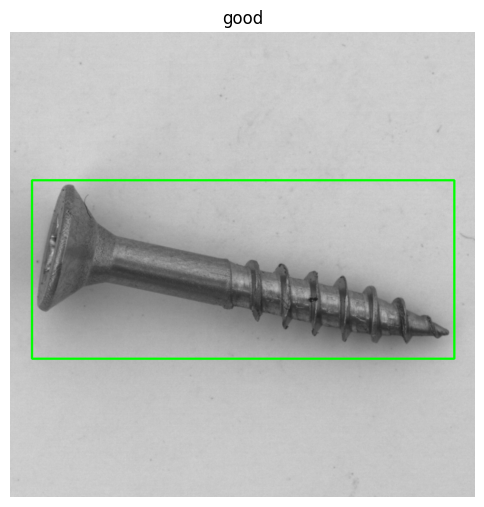

In [7]:
# ==========================================================
# Test Bounding Box Detection
# ==========================================================

sample = random.choice(all_images)

bbox = get_bbox(sample)

print("Sample Image :", sample.name)
print("Bounding Box :", bbox)

image = cv2.imread(str(sample))
display = image.copy()

if bbox is not None:
    x1, y1, x2, y2 = bbox

    cv2.rectangle(
        display,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        3
    )

plt.figure(figsize=(6, 8))
plt.imshow(cv2.cvtColor(display, cv2.COLOR_BGR2RGB))
plt.title(sample.parent.name)
plt.axis("off")
plt.show()

In [8]:
# ==========================================================
# Generate YOLO Dataset
# ==========================================================

# -------------------------------
# Train / Validation Split
# -------------------------------
train_images, val_images = train_test_split(
    all_images,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print(f"Training Images  : {len(train_images)}")
print(f"Validation Images: {len(val_images)}")


def write_yolo_dataset(image_list, image_folder, label_folder):
    """
    Saves images and YOLO labels.
    """

    skipped = 0

    for idx, img_path in enumerate(tqdm(image_list)):

        image = cv2.imread(str(img_path))

        if image is None:
            skipped += 1
            continue

        bbox = get_bbox(img_path)

        if bbox is None:
            skipped += 1
            continue

        x1, y1, x2, y2 = bbox

        h, w = image.shape[:2]

        # ---------------------------
        # Convert to YOLO format
        # ---------------------------
        xc = ((x1 + x2) / 2) / w
        yc = ((y1 + y2) / 2) / h

        bw = (x2 - x1) / w
        bh = (y2 - y1) / h

        filename = f"{idx:06d}"

        # Save image
        cv2.imwrite(
            str(image_folder / f"{filename}.png"),
            image
        )

        # Save label
        with open(label_folder / f"{filename}.txt", "w") as f:
            f.write(
                f"0 {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}\n"
            )

    return skipped


print("\nGenerating Training Dataset...")
train_skipped = write_yolo_dataset(
    train_images,
    TRAIN_IMG,
    TRAIN_LABEL
)

print("\nGenerating Validation Dataset...")
val_skipped = write_yolo_dataset(
    val_images,
    VAL_IMG,
    VAL_LABEL
)

print("\n" + "=" * 60)
print("Dataset Generation Complete")
print("=" * 60)

print(f"Training Images Saved   : {len(list(TRAIN_IMG.glob('*.png')))}")
print(f"Validation Images Saved : {len(list(VAL_IMG.glob('*.png')))}")

print(f"Training Labels         : {len(list(TRAIN_LABEL.glob('*.txt')))}")
print(f"Validation Labels       : {len(list(VAL_LABEL.glob('*.txt')))}")

print(f"Skipped Training Images : {train_skipped}")
print(f"Skipped Validation Images : {val_skipped}")

Training Images  : 384
Validation Images: 96

Generating Training Dataset...


100%|██████████| 384/384 [00:19<00:00, 19.65it/s]



Generating Validation Dataset...


100%|██████████| 96/96 [00:04<00:00, 20.28it/s]


Dataset Generation Complete
Training Images Saved   : 384
Validation Images Saved : 96
Training Labels         : 384
Validation Labels       : 96
Skipped Training Images : 0
Skipped Validation Images : 0


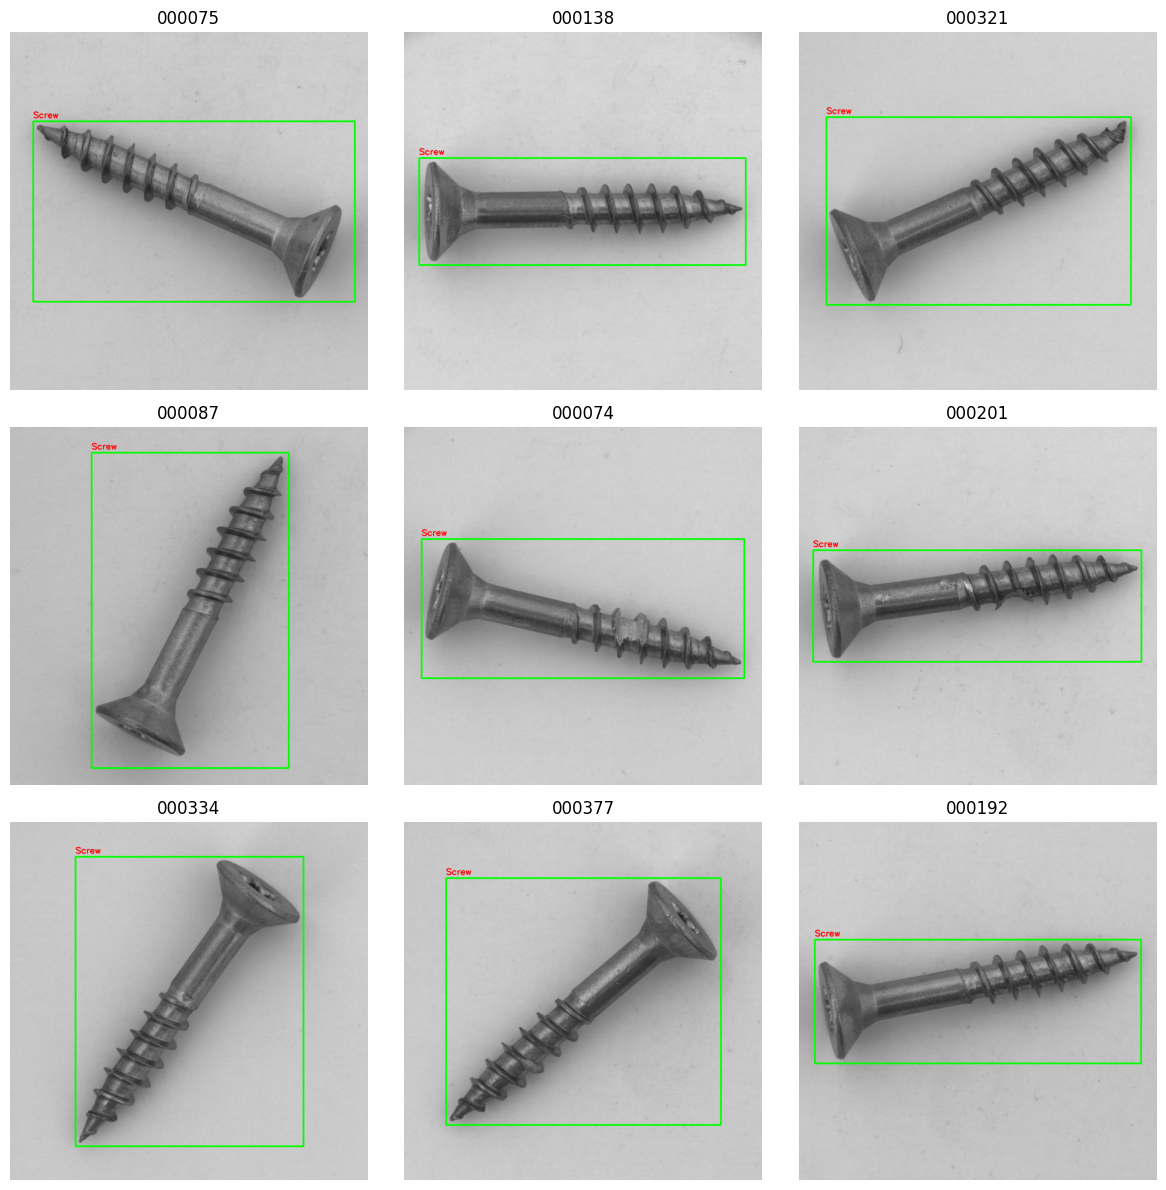

In [9]:
# ==========================================================
# Visualize Generated YOLO Labels
# ==========================================================

NUM_SAMPLES = 9

train_images = sorted(TRAIN_IMG.glob("*.png"))

assert len(train_images) > 0, "No training images found!"

samples = random.sample(
    train_images,
    min(NUM_SAMPLES, len(train_images))
)

plt.figure(figsize=(12, 12))

for i, img_path in enumerate(samples):

    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    label_path = TRAIN_LABEL / f"{img_path.stem}.txt"

    if label_path.exists():

        with open(label_path, "r") as f:

            line = f.readline().strip()

            if line:

                cls, xc, yc, bw, bh = map(float, line.split())

                x1 = int((xc - bw / 2) * w)
                y1 = int((yc - bh / 2) * h)

                x2 = int((xc + bw / 2) * w)
                y2 = int((yc + bh / 2) * h)

                cv2.rectangle(
                    image,
                    (x1, y1),
                    (x2, y2),
                    (0, 255, 0),
                    3
                )

                cv2.putText(
                    image,
                    "Screw",
                    (x1, max(25, y1 - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8,
                    (255, 0, 0),
                    2
                )

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(img_path.stem)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# NOTE: removed a duplicate/dead train-val split that used to live here.
# The actual split used to build the YOLO dataset happens above via
# train_test_split(), so no extra split is needed.
print("Skipping redundant split (dataset already generated above).")


Skipping redundant split (dataset already generated above).


In [11]:
# ==========================================================
# Create data.yaml
# ==========================================================

DATA_YAML = YOLO_ROOT / "data.yaml"

yaml_text = f"""
path: {YOLO_ROOT.as_posix()}

train: images/train
val: images/val

nc: 1

names:
  0: screw
"""

with open(DATA_YAML, "w") as f:
    f.write(yaml_text.strip())

print("=" * 60)
print("data.yaml Created Successfully")
print("=" * 60)
print(DATA_YAML)

print("\nContents:\n")
print(DATA_YAML.read_text())

data.yaml Created Successfully
d:\Projects\VisionXM\yolo_dataset\data.yaml

Contents:

path: d:/Projects/VisionXM/yolo_dataset

train: images/train
val: images/val

nc: 1

names:
  0: screw


In [12]:
# ==========================================================
# Dataset Integrity Check
# ==========================================================

def verify_dataset(images_dir, labels_dir, split_name):
    images = sorted(images_dir.glob("*.png"))
    labels = sorted(labels_dir.glob("*.txt"))

    print(f"\nChecking {split_name} Dataset...")

    print(f"Images : {len(images)}")
    print(f"Labels : {len(labels)}")

    missing_labels = []
    empty_labels = []
    orphan_labels = []

    image_stems = {img.stem for img in images}
    label_stems = {lbl.stem for lbl in labels}

    # Missing labels
    for img in images:
        label_path = labels_dir / f"{img.stem}.txt"

        if not label_path.exists():
            missing_labels.append(img.name)
            continue

        if label_path.stat().st_size == 0:
            empty_labels.append(label_path.name)

    # Orphan labels
    for lbl in labels:
        if lbl.stem not in image_stems:
            orphan_labels.append(lbl.name)

    print(f"Missing Labels : {len(missing_labels)}")
    print(f"Empty Labels   : {len(empty_labels)}")
    print(f"Orphan Labels  : {len(orphan_labels)}")

    if missing_labels:
        print("\nFirst Missing Labels:")
        print(missing_labels[:5])

    if empty_labels:
        print("\nFirst Empty Labels:")
        print(empty_labels[:5])

    if orphan_labels:
        print("\nFirst Orphan Labels:")
        print(orphan_labels[:5])

    assert len(missing_labels) == 0, "Dataset contains missing labels."
    assert len(empty_labels) == 0, "Dataset contains empty labels."
    assert len(orphan_labels) == 0, "Dataset contains orphan labels."

    print(f"✓ {split_name} Dataset OK")


print("=" * 60)
print("Verifying Dataset")
print("=" * 60)

verify_dataset(TRAIN_IMG, TRAIN_LABEL, "Training")
verify_dataset(VAL_IMG, VAL_LABEL, "Validation")

print("\n" + "=" * 60)
print("✓ DATASET READY FOR TRAINING")
print("=" * 60)

Verifying Dataset

Checking Training Dataset...
Images : 384
Labels : 384
Missing Labels : 0
Empty Labels   : 0
Orphan Labels  : 0
✓ Training Dataset OK

Checking Validation Dataset...
Images : 96
Labels : 96
Missing Labels : 0
Empty Labels   : 0
Orphan Labels  : 0
✓ Validation Dataset OK

✓ DATASET READY FOR TRAINING


In [13]:
# ==========================================================
# Train YOLOv8 Model
# ==========================================================
# FIX: the original notebook had NO training cell at all -- it jumped
# straight to loading "models/yolo_screw_detector/weights/best.pt" for
# evaluation, which can only exist after training has actually run.
# That's why the assert on BEST_MODEL.exists() failed. This cell trains
# the model and produces that checkpoint.

print("=" * 60)
print("Training YOLOv8 Model")
print("=" * 60)

yolo_model = YOLO("yolov8n.pt")  # start from pretrained COCO weights

device = 0 if torch.cuda.is_available() else "cpu"
print("Training device:", device)

train_results = yolo_model.train(
    data=str(DATA_YAML),
    epochs=50,
    imgsz=640,
    batch=16,
    device=device,
    project=str(MODELS_DIR),
    name="yolo_screw_detector",
    exist_ok=True,
)

print("\nTraining complete.")
print("Best weights saved to:", MODELS_DIR / "yolo_screw_detector" / "weights" / "best.pt")


Training YOLOv8 Model
Training device: 0
New https://pypi.org/project/ultralytics/8.4.115 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.104  Python-3.10.11 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=d:\Projects\VisionXM\yolo_dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, l

In [14]:
# ==========================================================
# Evaluate Trained YOLOv8 Model
# ==========================================================
# FIX: this used to be duplicated across two nearly-identical cells with a
# hardcoded device=0 (GPU-only). Consolidated into a single cell with a
# dynamic device selection so it also works on CPU-only machines.

print("=" * 60)
print("Evaluating YOLOv8 Model")
print("=" * 60)

BEST_MODEL = MODELS_DIR / "yolo_screw_detector" / "weights" / "best.pt"
assert BEST_MODEL.exists(), f"Model not found:\n{BEST_MODEL}\n(Run the training cell above first.)"

model = YOLO(str(BEST_MODEL))

metrics = model.val(
    data=str(DATA_YAML),
    split="val",
    imgsz=640,
    batch=16,
    device=0 if torch.cuda.is_available() else "cpu",
    workers=4,
    project=str(MODELS_DIR),
    name="validation",
    exist_ok=True,
    plots=True,
    verbose=True,
)

print("\n" + "=" * 60)
print("Validation Metrics")
print("=" * 60)

print(f"Precision (P):    {metrics.box.mp:.4f}")
print(f"Recall (R):       {metrics.box.mr:.4f}")
print(f"mAP@50:           {metrics.box.map50:.4f}")
print(f"mAP@50-95:        {metrics.box.map:.4f}")

print("\nEvaluation Complete!")
print("\nValidation artifacts saved to:")
print(MODELS_DIR / "validation")


Evaluating YOLOv8 Model
Ultralytics 8.4.104  Python-3.10.11 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Laptop GPU, 8151MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 749.5461.6 MB/s, size: 1068.8 KB)
val: Scanning D:\Projects\VisionXM\yolo_dataset\labels\val.cache... 96 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 96/96  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 7.6s/it 45.6s1.0s3s
                   all         96         96      0.999          1      0.995      0.991
Speed: 3.9ms preprocess, 11.9ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to D:\Projects\VisionXM\models\validation

Validation Metrics
Precision (P):    0.9994
Recall (R):       1.0000
mAP@50:           0.9950
mAP@50-95:        0.9911

Evaluation Complete!

Validation artifacts saved to:
d:\Projects\VisionXM\models\validatio